<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 123 · Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Segmentation &amp; Targeting &#183; Take It Further</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Five extensions of the campaign: choosing the number of segments, a gradient-boosting propensity model, a calibration check, a cost-to-value sensitivity sweep, and building an actual contact list under budget, each with a picture and a plain-English explanation.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Segmentation & Targeting: Take It Further
Five extensions of the Chapter 123 campaign, each with a picture and a plain explanation: choose the number of segments properly, try a **gradient-boosting** propensity model, check the scores are **calibrated** (the ROI math depends on it), sweep the **cost-to-value ratio**, and build an actual **contact list under a budget**. We start by rebuilding the segments and the propensity model.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import silhouette_score, roc_auc_score
import warnings; warnings.filterwarnings('ignore')

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">RECAP &#183; REBUILD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Segments, split, propensity model</div>
<div style="color:#4a5578;margin-top:6px">Everything from Chapter 123 in a few cells.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/marketing_campaign.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'marketing_campaign.csv')
df = df.drop_duplicates('customer_id').reset_index(drop=True)
feats = ['recency_days','frequency','monetary','tenure_months','email_opens_90d','prior_responses','age']
seg_pipe = Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())]); Xs = seg_pipe.fit_transform(df[feats])
X = df[feats]; y = df['responded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0, stratify=y)
model = Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler()),('c',LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
prob = model.predict_proba(X_test)[:,1]
print('recap: propensity ROC-AUC = %.3f | response rate %.1f%%' % (roc_auc_score(y_test, prob), y.mean()*100))

recap: propensity ROC-AUC = 0.866 | response rate 20.9%


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 1 &#183; HOW MANY SEGMENTS?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Elbow and silhouette together</div>
<div style="color:#4a5578;margin-top:6px">Let two diagnostics guide the choice.</div>
</div>

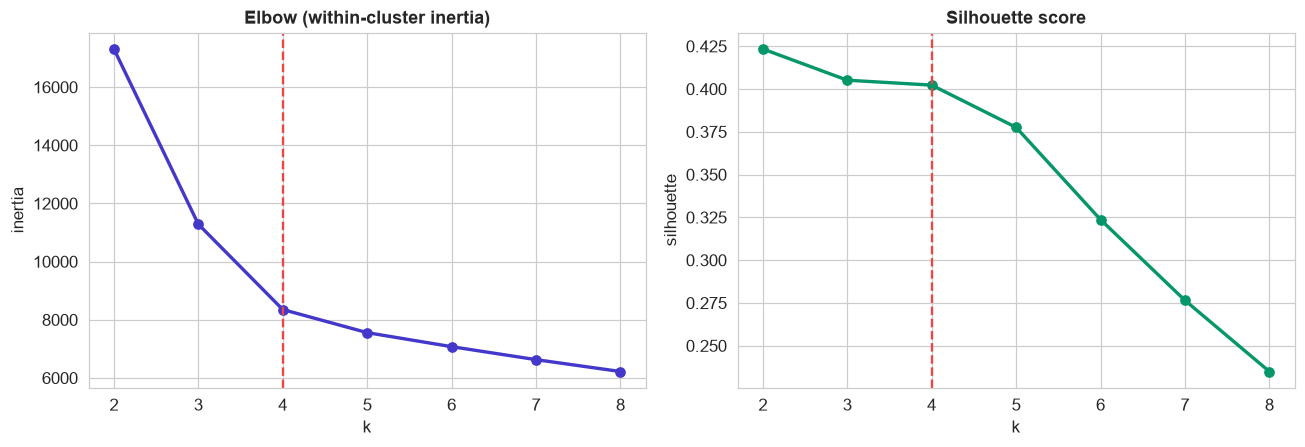

silhouette gently declines with k; the elbow bends around 3-4; we choose 4 for actionability


In [4]:
ks = range(2, 9)
inertia = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs).inertia_ for k in ks]
sil = [silhouette_score(Xs, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)) for k in ks]
fig, ax = plt.subplots(1, 2, figsize=(12,4.2))
ax[0].plot(list(ks), inertia, 'o-', color=EM, lw=2.2); ax[0].axvline(4, color=RED, ls='--'); ax[0].set(title='Elbow (within-cluster inertia)', xlabel='k', ylabel='inertia')
ax[1].plot(list(ks), sil, 'o-', color=GREEN, lw=2.2); ax[1].axvline(4, color=RED, ls='--'); ax[1].set(title='Silhouette score', xlabel='k', ylabel='silhouette')
plt.tight_layout(); plt.show()
print('silhouette gently declines with k; the elbow bends around 3-4; we choose 4 for actionability')

**k is a judgement call.** The elbow in the inertia curve softens around three or four clusters, and the silhouette declines gently from its k=2 peak. Neither screams a single answer, which is typical of real customer data. We settle on **four** because the resulting segments are distinct and *nameable*, Champions, Loyal, New, Lapsed, and a marketer can act on four groups. Clustering serves the business question, not the other way around.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 2 &#183; A GRADIENT-BOOSTING PROPENSITY MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does a flexible model target better?</div>
<div style="color:#4a5578;margin-top:6px">Compare the gains curves.</div>
</div>

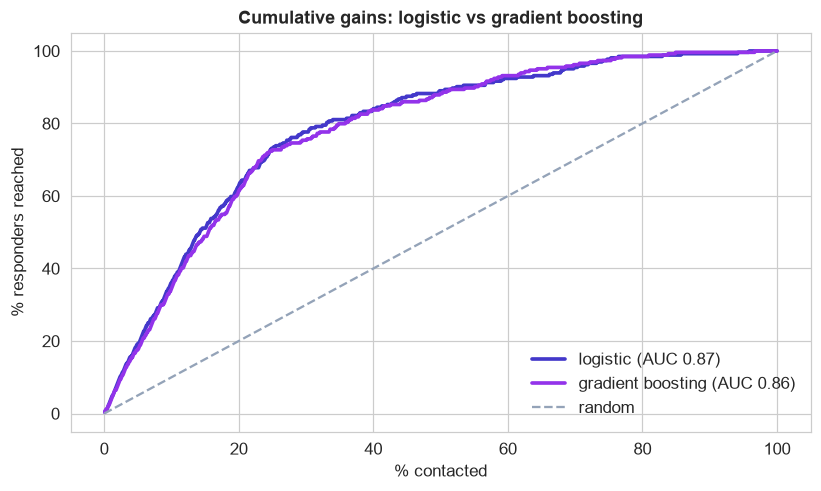

In [5]:
gb = Pipeline([('i',SimpleImputer(strategy='median')),('c',GradientBoostingClassifier(random_state=0))]).fit(X_train, y_train)
gb_prob = gb.predict_proba(X_test)[:,1]
def gains(p):
    o = np.argsort(-p); return np.cumsum(y_test.values[o])/y_test.sum(), np.arange(1,len(p)+1)/len(p)
fig, ax = plt.subplots(figsize=(7.6,4.6))
for name,p,c in [('logistic',prob,EM),('gradient boosting',gb_prob,PUR)]:
    g,pct = gains(p); ax.plot(pct*100, g*100, color=c, lw=2.4, label=f'{name} (AUC {roc_auc_score(y_test,p):.2f})')
ax.plot([0,100],[0,100],'--',color=GREY,label='random')
ax.set(title='Cumulative gains: logistic vs gradient boosting', xlabel='% contacted', ylabel='% responders reached'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**Both target well; pick the one you can explain.** The gradient-boosting model lands very close to the logistic model on the gains curve, either would build a similar contact list. Because the two are neck and neck and the logistic model is transparent (clear response drivers, calibrated scores), it remains the sensible default; the boosted model is worth keeping only if it opens a clear, sustained gap.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 3 &#183; ARE THE SCORES CALIBRATED?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The ROI math needs real probabilities</div>
<div style="color:#4a5578;margin-top:6px">A '20%' score should respond 20% of the time.</div>
</div>

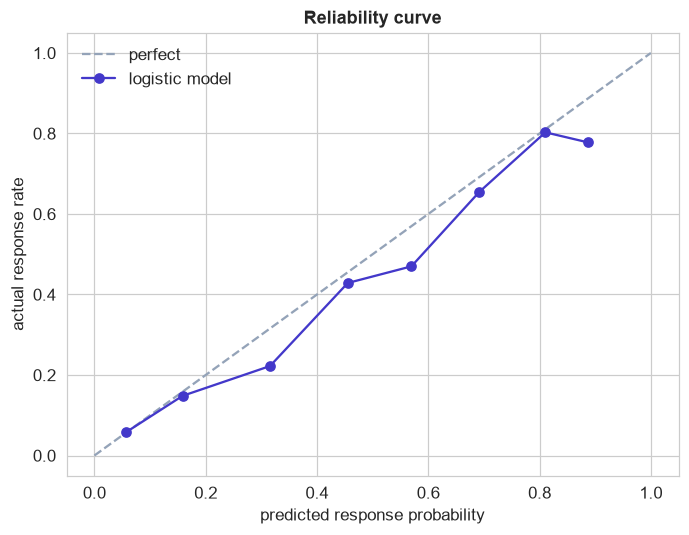

the points track the diagonal, so a predicted 20%% really does respond about 20%% of the time


In [6]:
fig, ax = plt.subplots(figsize=(6.4,5))
frac, mean_pred = calibration_curve(y_test, prob, n_bins=8)
ax.plot([0,1],[0,1],'--',color=GREY,label='perfect'); ax.plot(mean_pred, frac, 'o-', color=EM, label='logistic model')
ax.set(xlabel='predicted response probability', ylabel='actual response rate', title='Reliability curve'); ax.legend()
plt.tight_layout(); plt.show()
print('the points track the diagonal, so a predicted 20%% really does respond about 20%% of the time')

**Calibration is what makes the ROI honest.** The whole profit calculation multiplies a customer's response *probability* by the response value, so those probabilities must mean what they say. The reliability curve, predicted probability versus actual response rate, hugs the diagonal, so the logistic scores are trustworthy expected values, not just a ranking. Had they been miscalibrated, we would wrap the model in `CalibratedClassifierCV` before computing ROI.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 4 &#183; WHEN TO TARGET MORE (OR LESS)</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sweep the cost-to-value ratio</div>
<div style="color:#4a5578;margin-top:6px">Cheaper contact means reach deeper.</div>
</div>

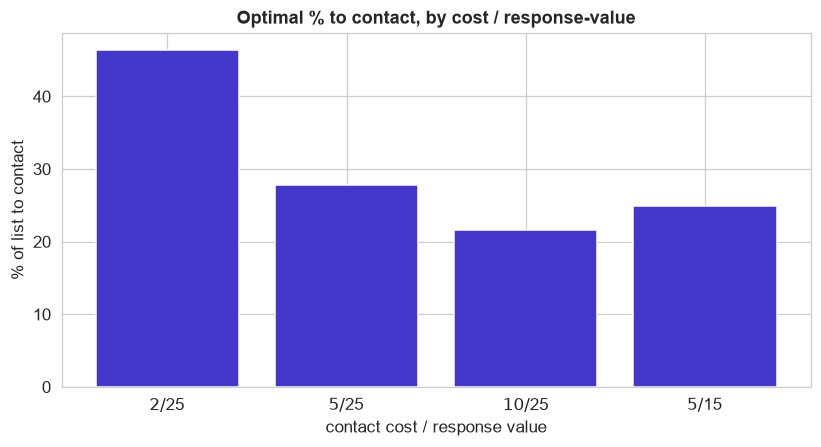

cost/value $2/$25: contact top 46%
cost/value $5/$25: contact top 28%
cost/value $10/$25: contact top 22%
cost/value $5/$15: contact top 25%


In [7]:
order = np.argsort(-prob); resp_sorted = y_test.values[order]; n = len(order)
cum_resp = np.cumsum(resp_sorted); contacted = np.arange(1, n+1)
scenarios = [(2,25),(5,25),(10,25),(5,15)]
opt = []
for cost, value in scenarios:
    profit = cum_resp*value - contacted*cost; opt.append((f'${cost}/${value}', (np.argmax(profit)+1)/n*100))
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.bar([o[0] for o in opt], [o[1] for o in opt], color=EM)
ax.set(title='Optimal % to contact, by cost / response-value', ylabel='% of list to contact', xlabel='contact cost / response value'); plt.tight_layout(); plt.show()
for label, pctg in opt: print(f'cost/value {label}: contact top {pctg:.0f}%')

**The target size follows the economics.** When a contact is cheap relative to a response (a $2 email for a $25 sale), it pays to reach deep into the list, even fairly unlikely responders are worth an email. When contact is expensive (a $10 mailer, or a low-value response), the optimal list shrinks to only the highest-propensity customers. There is no fixed 'right' fraction to target; it falls directly out of the cost-to-value ratio, a business input.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 5 &#183; BUILD THE CONTACT LIST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A fixed budget, the best customers</div>
<div style="color:#4a5578;margin-top:6px">Turn scores into an actual campaign.</div>
</div>

In [8]:
BUDGET = 300     # we can afford to contact 300 customers
scored = X_test.copy(); scored['prob'] = prob; scored['responded'] = y_test.values
contact_list = scored.sort_values('prob', ascending=False).head(BUDGET)
exp_responses = contact_list.prob.sum()
actual_responses = contact_list.responded.sum()
print(f'contacting the top {BUDGET} customers by propensity:')
print(f'  expected responses (sum of probabilities): {exp_responses:.0f}')
print(f'  actual responses in this test set:         {actual_responses}')
print(f'  response rate on the list: {actual_responses/BUDGET:.0%}  vs  {y_test.mean():.0%} for a random {BUDGET}')
print(f'  profit at $25/response, $5/contact: ${actual_responses*25 - BUDGET*5}')

contacting the top 300 customers by propensity:
  expected responses (sum of probabilities): 202
  actual responses in this test set:         185
  response rate on the list: 62%  vs  21% for a random 300
  profit at $25/response, $5/contact: $3125


**This is the deliverable.** Given a budget to reach 300 customers, we simply take the 300 highest-propensity people. Their response rate is far above the base rate, so the campaign captures many responders for the fixed spend, and the sum of their probabilities is a live forecast of how many responses to expect. This ranked list, refreshed as customers behave, is exactly what a marketing team runs, and pairing it with an untouched control group proves the incremental lift.

## Take-it-further summary, in plain terms

- **Choosing the number of segments is a judgement call**: the diagnostics guide, but actionability decides (four nameable groups).
- **A boosted model targets about as well as the logistic one**, so keep the transparent, calibrated model.
- **Calibrated probabilities make the ROI trustworthy**, a predicted 20% really responds about 20% of the time.
- **How deep to target follows the cost-to-value ratio**: cheap contact, reach far; expensive contact, target the top.
- **The deliverable is a ranked contact list** under budget, with a forecast of responses and a control group to prove lift.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>